# Upstream material notice

This notebook is adapted from an upstream Krusell-Smith JAX tutorial. The original upstream title, authorship, and license notice are preserved in the cell(s) immediately below this one — do not modify them.

## Course placement

**Used in:** Lecture 17 (B16): Sequence-Space DEQNs (extension)  
**Original live-course source:** `lectures/day4/code/KrusellSmith_Tutorial_CPU.ipynb`  
**Course adaptation:** `TUTORIAL_MODE` switch added to bound runtime to ~7 min CPU.  
**Course author of this adaptation:** Simon Scheidegger  
**License:** see repository `LICENSE` and `LICENSE-content.md`; upstream license preserved verbatim below.

In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


> **Smoke mode.** This notebook is long-running at production settings. The cell above sets `RUN_MODE="smoke"` so that the bound branch in the first hyperparameter cell below caps epochs / batch size / sample count to keep CPU runtime under ~3 minutes. To reproduce paper-quality results, switch to `"teaching"` or `"production"` (GPU recommended). See `COURSE_MAP.md` for the convention.

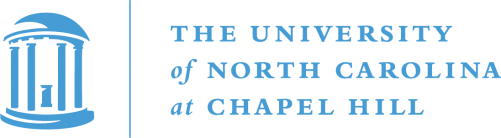

# Solving the Krusell-Smith Model with Deep Learning in the Sequence Space

This notebook is the **JAX reference** for the sequence-space DEQN material on Day 4 of *Deep Learning in Economics and Finance*.

It is adapted from the upstream pedagogical notebook `01_KrusellSmith_Tutorial_CPU.ipynb` released with the paper [Deep Learning in the Sequence Space](https://arxiv.org/abs/2509.13623) by [Marlon Azinovic-Yang](https://sites.google.com/view/marlonazinovic/home) and [Jan Žemlička](https://janzemlicka.crd.co/).

- **Upstream repository:** <https://github.com/azinoma/DeepLearningInTheSequenceSpace>
- **Paper:** Azinovic-Yang & Žemlička (2025), arXiv:2509.13623

The local adaptation only adds (i) a `TUTORIAL_MODE` switch with a smaller classroom-friendly configuration, (ii) an explicit shape-guarantee diagnostic, and (iii) clarifying comments. The mathematics and the algorithm are unchanged.

**Recommended workflow**
- Start with `TUTORIAL_MODE = "quick"` so the notebook runs in a few minutes on a laptop CPU.
- Switch to `"full"` once the pipeline is clear.
- If the import cell complains about missing packages, install them with `pip install jax optax scipy matplotlib` and rerun.

**Important note on `K_ss`.** The deterministic representative-agent benchmark `K_ss` defined below is only a convenient reference point for plots and initial conditions. It is **not** the stochastic heterogeneous-agent equilibrium capital stock.

In [1]:
import jax
import jax.numpy as jnp
from jax import lax
import matplotlib.pyplot as plt
import numpy as np
import optax
from scipy.interpolate import BSpline

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

TUTORIAL_MODE = "quick"  # change to "full" for the larger, slower run
assert TUTORIAL_MODE in {"quick", "full"}
print(f"Tutorial mode: {TUTORIAL_MODE}")


JAX version: 0.6.2
Devices: [CpuDevice(id=0)]
Tutorial mode: quick


---
# Part 1: The Economic Model

## The Krusell-Smith Economy

We consider an economy with:
- A **continuum of households** who save and consume
- **Aggregate risk**: productivity $Z_t \in \{Z_L, Z_H\}$ follows a Markov chain
- **Idiosyncratic risk**: each household's efficiency $\varepsilon_t \in \{\varepsilon_L, \varepsilon_H\}$ also follows a Markov chain

### Prices
A representative firm uses Cobb-Douglas technology $Y = Z K^\alpha L^{1-\alpha}$, giving:

$$R_t = 1 - \delta + \alpha Z_t (K_t / L_t)^{\alpha - 1}$$
$$w_t = (1 - \alpha) Z_t (K_t / L_t)^{\alpha}$$

### Household Problem
Each household chooses consumption $c_t$ to maximize:
$$\max \; \mathbb{E}_0 \sum_{t=0}^{\infty} \beta^t \log(c_t)$$
subject to:
$$c_t + k_{t+1} = w_t \varepsilon_t + R_t k_t, \qquad k_{t+1} \geq 0$$

### Optimality Conditions
At an **interior solution** ($k_{t+1} > 0$), the Euler equation holds:
$$u'(c_t) = \beta \, \mathbb{E}_t [R_{t+1} \, u'(c_{t+1})]$$

At the **borrowing constraint** ($k_{t+1} = 0$), the Euler gap can be nonzero, but the Kuhn-Tucker conditions still have to hold.

For teaching purposes, this notebook keeps the Markov structure deliberately simple: both aggregate and idiosyncratic shocks have **two states**.

## Calibration

Let's set up the model parameters:

In [2]:
#===Model Parameters===
ALPHA = 0.36   # capital share
DELTA = 0.025  # depreciation
BETA = 0.93    # discount factor (log utility is hardcoded throughout)

# Idiosyncratic shocks: low and high efficiency
EPS_VALS = jnp.array([0.5, 1.5])
PI_EPS = jnp.array([[0.9, 0.1],  # P(eps'=L | eps=L) = 0.9
                     [0.1, 0.9]]) # P(eps'=H | eps=H) = 0.9

# Aggregate shocks: low and high productivity
Z_VALS = jnp.array([0.93, 1.07])
PI_Z = jnp.array([[0.7, 0.3],  # persistence = 0.7
                  [0.3, 0.7]])

N_EPS = len(EPS_VALS)
N_Z = len(Z_VALS)

# Steady-state capital (from the deterministic Euler equation)
R_ss = 1.0 / BETA
K_ss = ((R_ss - 1.0 + DELTA) / ALPHA) ** (1.0 / (ALPHA - 1.0))
print(f"Steady-state capital: K_ss = {K_ss:.2f}")

# Price functions
def compute_prices(K, L, Z):
    """
    Cobb-Douglas factor prices.
    """
    KL = K / L
    R = 1.0 - DELTA + ALPHA * Z * KL ** (ALPHA - 1.0)
    w = (1.0 - ALPHA) * Z * KL ** ALPHA
    return R, w

Steady-state capital: K_ss = 7.37


---
# Part 2: The I-Spline MPC Representation

## Shape preserving operator learning
For a given aggregate history of shocks, $Z^t$, we want to predict a consumption *function* $c(\varepsilon, k)$. Following the *operator learning* idea, we want to predict the consumption values on a grid of idisyncratic states, and then use piecewise linear interpolation inbetween.

We want a consumption function $c(\varepsilon, k)$ that is:
- **Increasing** in $k$ (richer people consume more)
- **Concave** in $k$ (the marginal propensity to consume decreases with wealth)
- **Feasible**: $0 < c < w\varepsilon + Rk$ (no borrowing, positive consumption)

Instead of parameterizing $c$ directly, we parameterize the **marginal propensity to consume (MPC)** — how much of each extra dollar of wealth gets consumed:

$$\text{MPC}(\varepsilon, k) = \alpha(\varepsilon) \left(1 - \sum_{j=1}^J \tilde{w}_j(\varepsilon) \, I_j(k)\right)$$

where:
- $\alpha \in (0,1)$: MPC at the borrowing constraint (from a sigmoid)
- $I_j(k)$: **I-spline basis functions** (monotonically increasing from 0 to 1)
- $\tilde{w}_j \geq 0, \sum \tilde{w}_j < 1$: weights from a "phantom-zero" softmax

Since each $I_j$ is increasing and $\tilde{w}_j \geq 0$, the MPC is **decreasing by construction**.
Since $\sum \tilde{w}_j < 1$, the MPC is **positive everywhere**.
Since $\alpha < 1$, consumption is **feasible**.

We then recover consumption by **cumulation** on a fixed grid:
$$c(k_0) = \text{MPC}(k_0) \cdot m(k_0), \qquad c(k_n) = c(k_{n-1}) + \text{MPC}(k_n) \cdot R \cdot \Delta k_n$$

## Let's build it step by step.

### Step 2a: The Capital Grid

We use a log-spaced grid to get more resolution near $k=0$ where the policy is steepest:

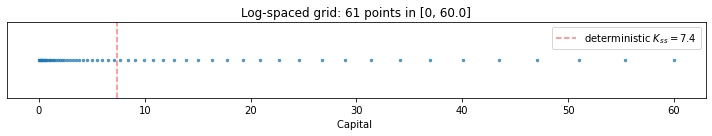

Grid spacing: 0.042 (near k=0) to 4.6 (near k_max)


In [3]:

# === Capital Grid ===
GRID_CONFIG = {
    "quick": {"N": 60, "K_MAX": 60.0},
    "full": {"N": 100, "K_MAX": 100.0},
}[TUTORIAL_MODE]

N = GRID_CONFIG["N"]          # number of intervals (N+1 grid points)
K_MAX = GRID_CONFIG["K_MAX"]  # upper bound on capital

K_GRID_SHIFT = 0.5
BASIS_SHIFT = 0.5  

x_grid = np.linspace(np.log(K_GRID_SHIFT), np.log(K_MAX + K_GRID_SHIFT), N + 1)
k_grid = jnp.array(np.exp(x_grid) - K_GRID_SHIFT)
dk = jnp.diff(k_grid)
x0 = float(x_grid[0])
delta_x = float((x_grid[-1] - x_grid[0]) / N)

# Visualize the grid spacing
fig, ax = plt.subplots(figsize=(10, 2))
ax.scatter(np.asarray(k_grid), np.zeros(N + 1), s=6, alpha=0.7)
ax.set_xlabel("Capital ")
ax.set_title(f"Log-spaced grid: {N+1} points in [0, {K_MAX}]")
ax.set_yticks([])
ax.axvline(K_ss, color='red', linestyle='--', alpha=0.5, label=f"deterministic $K_{{ss}}={K_ss:.1f}$")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Grid spacing: {float(dk[0]):.3f} (near k=0) to {float(dk[-1]):.1f} (near k_max)")

### Step 2b: I-Spline Basis Functions

It helps to separate the **grid** from the **basis**.

- The policy grid `k_grid = (k_0,\dots,k_N)` tells us **where** we store the policy.
- The I-spline basis tells us **how we parameterize the shape** of the MPC on that grid.

We build cubic I-splines in the transformed coordinate
\begin{align}
x = \log(BASIS\_SHIFT + k).
\end{align}
The spline **knots** live in this `x`-space; they are not the same as the points in `k_grid`.

After constructing the basis functions $I_1,\dots,I_J$, we evaluate each one at every grid point
\begin{align}
B_{j,n} &= I_j(\log(BASIS\_SHIFT + k_n)),\\
j&=1,\dots,J,\; n=0,\dots,N.
\end{align}
So `ispline_basis` is a matrix $B \in \mathbb{R}^{J \times (N+1)}$:  
rows = basis functions, columns = capital grid points.

Each I-spline is a smooth **cumulative switch**: it starts near 0, rises over a local region, and ends near 1.  
Because each $I_j$ is increasing, any nonnegative weighted sum of them is also increasing.

The neural network outputs, for each income state:

- a boundary MPC $\alpha \in (0,1)$
- nonnegative weights $\tilde w_j$ with $\sum_j \tilde w_j < 1$

These define the MPC on the grid:
\begin{align}
\text{MPC}(k_n) = \alpha\left(1-\sum_{j=1}^J \tilde w_j B_{j,n}\right).
\end{align}

Since the weighted sum $\sum_j \tilde w_j B_{j,n}$ increases with $k_n$, the MPC decreases with $k_n$.  
That gives us concavity by construction.

We then recover consumption on the grid by discrete integration:
\begin{align}
c(k_0)&=\text{MPC}(k_0)\,m(k_0),\\
c(k_n)&=c(k_{n-1})+\text{MPC}(k_n)\,R\,(k_n-k_{n-1}).
\end{align}

A crucial point: the splines are used to construct the **MPC values on the grid**.  
Off the grid, the notebook does **not** use spline interpolation of $c(k)$; it uses simple piecewise-linear interpolation of `c_grid`.

Built 30 I-spline basis functions on 61 grid points
Basis matrix shape: (30, 61)
Entry B[j, n] = I_j(log(0.50 + k_grid[n]))


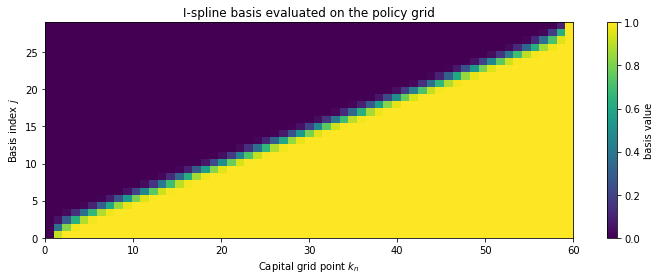

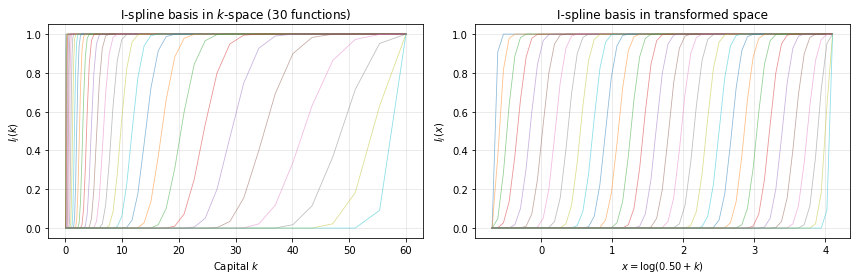

In [4]:
# === Build I-Spline Basis ===
N_INTERIOR = 26 if TUTORIAL_MODE == "quick" else 56
ORDER = 4           # cubic I-splines

def build_ispline_basis(k_grid, n_interior=56, order=4, basis_shift=None):
    """Precompute I-spline basis at the grid points."""
    if basis_shift is None:
        basis_shift = BASIS_SHIFT
    k_arr = np.asarray(k_grid)
    x = np.log(basis_shift + k_arr)
    x_min, x_max = float(x[0]), float(x[-1])

    # Equidistant interior knots in x-space
    knots_int = np.linspace(x_min, x_max, n_interior + 2)[1:-1]
    knots = np.concatenate([np.repeat(x_min, order), knots_int, np.repeat(x_max, order)])
    n_basis = len(knots) - order

    # Compute I-splines (= integral of B-splines)
    basis = np.zeros((n_basis, len(k_arr)))
    for idx in range(n_basis):
        c = np.zeros(n_basis)
        c[idx] = 1.0
        bspl = BSpline(knots, c, order - 1, extrapolate=False)
        t_span = knots[idx + order] - knots[idx]
        if t_span < 1e-12:
            continue
        anti = bspl.antiderivative()
        basis[idx] = (order / t_span) * np.nan_to_num(anti(x) - anti(x_min), 0.0)

    return jnp.array(np.clip(basis, 0.0, 1.0))

ispline_basis = build_ispline_basis(k_grid, N_INTERIOR, ORDER, basis_shift=BASIS_SHIFT)
J = ispline_basis.shape[0]
print(f"Built {J} I-spline basis functions on {N+1} grid points")


# What the basis matrix actually is
B = np.asarray(ispline_basis)
print("Basis matrix shape:", B.shape)
print(f"Entry B[j, n] = I_j(log({BASIS_SHIFT:.2f} + k_grid[n]))")

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(
    B,
    aspect='auto',
    origin='lower',
    extent=[float(k_grid[0]), float(k_grid[-1]), 0, B.shape[0]-1]
)
ax.set_xlabel("Capital grid point $k_n$")
ax.set_ylabel("Basis index $j$")
ax.set_title("I-spline basis evaluated on the policy grid")
fig.colorbar(im, ax=ax, label="basis value")
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for j in range(J):
    axes[0].plot(np.asarray(k_grid), np.asarray(ispline_basis[j]), linewidth=0.8, alpha=0.5)
axes[0].set_xlabel("Capital $k$")
axes[0].set_ylabel("$I_j(k)$")
axes[0].set_title(f"I-spline basis in $k$-space ({J} functions)")
axes[0].grid(True, alpha=0.3)

x_vals = np.log(BASIS_SHIFT + np.asarray(k_grid))
for j in range(J):
    axes[1].plot(x_vals, np.asarray(ispline_basis[j]), linewidth=0.8, alpha=0.5)
axes[1].set_xlabel(rf"$x = \log({BASIS_SHIFT:.2f} + k)$")
axes[1].set_ylabel("$I_j(x)$")
axes[1].set_title("I-spline basis in transformed space")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### Step 2c: The Neural Network Actor

The actor is a simple 2-layer MLP that maps a **short history of aggregate shocks** to I-spline coefficients.

This is a **practical approximation** to the Krusell-Smith idea that the wealth distribution can often be summarized well by a low-dimensional object. Here we use a finite shock history rather than claiming that the full distribution is literally a function of the last $H$ shocks.

In [5]:
# === Neural Network Actor ===
H = 50            # history length (last H aggregate shocks)
HIDDEN_DIM = 64   # MLP hidden layer width
INPUT_DIM = H * (N_Z + 1)  # one-hot + value per lag

def init_actor(key, input_dim, hidden_dim, n_eps, J):
    """Initialize a 2-hidden-layer MLP."""
    k1, k2, k3 = jax.random.split(key, 3)
    output_dim = n_eps * (1 + J)  # per eps: 1 alpha logit + J weight logits
    return {
        "W_0": jnp.sqrt(2.0/input_dim) * jax.random.normal(k1, (input_dim, hidden_dim)),
        "b_0": jnp.zeros(hidden_dim),
        "W_1": jnp.sqrt(2.0/hidden_dim) * jax.random.normal(k2, (hidden_dim, hidden_dim)),
        "b_1": jnp.zeros(hidden_dim),
        "W_2": 0.01 * jax.random.normal(k3, (hidden_dim, output_dim)),
        "b_2": jnp.zeros(output_dim),
    }

def actor_c_grid(psi, agg_input, R, w):
    """Forward pass: aggregate input -> consumption on the k-grid.

    Returns: c_grid of shape (n_eps, N+1)
    """
    # MLP forward pass (tanh activation — sweep-validated, 3x better than relu)
    h = jnp.tanh(agg_input @ psi["W_0"] + psi["b_0"])
    h = jnp.tanh(h @ psi["W_1"] + psi["b_1"])
    raw = (h @ psi["W_2"] + psi["b_2"]).reshape(N_EPS, 1 + J)

    # Boundary MPC: sigmoid -> (0, 1)
    alpha = jax.nn.sigmoid(raw[:, 0])                        # (n_eps,)

    # Phantom-zero softmax: guarantees weights >= 0 and sum < 1
    logits = raw[:, 1:]                                       # (n_eps, J)
    augmented = jnp.concatenate([jnp.zeros((N_EPS, 1)), logits], axis=1)
    w_tilde = jax.nn.softmax(augmented, axis=1)[:, 1:]       # (n_eps, J)

    # MPC on the grid: alpha * (1 - weighted I-splines)
    mpc = alpha[:, None] * (1.0 - w_tilde @ ispline_basis)   # (n_eps, N+1)

    # Cumulate consumption on the grid from the MPC schedule.
    # Boundary: c(k_0) = MPC(k_0) · m(k_0), where m = wε + Rk is cash-on-hand
    c0 = mpc[:, 0] * (w * EPS_VALS + R * k_grid[0])
    # Increments: Δc_n = MPC(k_n) · R · Δk_n — each MPC value used exactly once
    dc = mpc[:, 1:] * (R * dk[None, :])
    c_grid = jnp.concatenate([c0[:, None], c0[:, None] + jnp.cumsum(dc, axis=1)], axis=1)
    return c_grid

# Initialize and check
key = jax.random.PRNGKey(0)
key, init_key = jax.random.split(key)
psi = init_actor(init_key, INPUT_DIM, HIDDEN_DIM, N_EPS, J)
n_params = sum(p.size for p in jax.tree_util.tree_leaves(psi))
print(f"Actor parameters: {n_params}")
print(f"Input dim: {INPUT_DIM} (H={H} x {N_Z+1} features per lag)")
print(f"Output dim: {N_EPS} x (1 + {J}) = {N_EPS * (1 + J)}")

Actor parameters: 17854
Input dim: 150 (H=50 x 3 features per lag)
Output dim: 2 x (1 + 30) = 62


Let's visualize what the **initial (random) policy** looks like. Even before training, the shape guarantees hold:

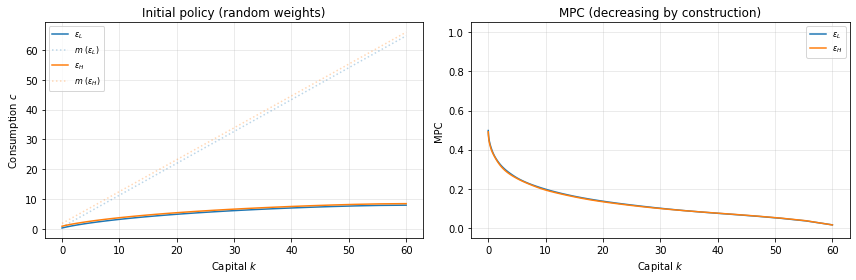

Shape check for initial random policy:
  min Δc across grid intervals      =  2.084e-02  (should be >= 0)
  max(c - cash on hand)             = -3.068e-01  (should be <= 0)
  MPC range on intervals            = [ 0.016,  0.476]
  max increase in MPC across k-grid = -6.322e-03  (should be <= 0)
Even before training, the grid policy is increasing, feasible, and concave by construction.


In [6]:
# === Visualize Initial Policy ===
def encode_Z_history(z_hist):
    """Encode Z-history as one-hot + values."""
    onehot = jax.nn.one_hot(z_hist, N_Z).reshape(-1)
    values = Z_VALS[z_hist].reshape(-1)
    return jnp.concatenate([onehot, values])

def shape_report(c_grid, R, w, title):
    """Verify the four shape guarantees of the I-spline MPC policy.

    Checks (all should hold by construction):
      min Δc >= 0        — consumption is increasing in k
      max(c - m) <= 0    — consumption is feasible (c ≤ cash-on-hand)
      MPC ∈ [0, 1]       — marginal propensity in valid range
      max ΔMPC <= 0      — MPC is decreasing (consumption is concave)
    """
    m_grid = float(w) * np.asarray(EPS_VALS)[:, None] + float(R) * k_np[None, :]
    min_dc = float(np.min(np.diff(c_grid, axis=1)))
    max_excess = float(np.max(c_grid - m_grid))
    mpc_intervals = np.diff(c_grid, axis=1) / (float(R) * np.asarray(dk)[None, :])
    min_mpc = float(np.min(mpc_intervals))
    max_mpc = float(np.max(mpc_intervals))
    max_upturn = float(np.max(np.diff(mpc_intervals, axis=1)))
    print(f"Shape check for {title}:")
    print(f"  min Δc across grid intervals      = {min_dc: .3e}  (should be >= 0)")
    print(f"  max(c - cash on hand)             = {max_excess: .3e}  (should be <= 0)")
    print(f"  MPC range on intervals            = [{min_mpc: .3f}, {max_mpc: .3f}]")
    print(f"  max increase in MPC across k-grid = {max_upturn: .3e}  (should be <= 0)")

# Use a constant Z=Z_L history for visualization
z_hist_dummy = jnp.zeros(H, dtype=jnp.int32)
agg_input = encode_Z_history(z_hist_dummy)
R_vis, w_vis = compute_prices(K_ss, 1.0, float(Z_VALS[0]))
c_grid_init = np.asarray(actor_c_grid(psi, agg_input, float(R_vis), float(w_vis)))

k_np = np.asarray(k_grid)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#1f77b4", "#ff7f0e"]
labels = [r"$\varepsilon_L$", r"$\varepsilon_H$"]

for e in range(N_EPS):
    m = float(w_vis) * float(EPS_VALS[e]) + float(R_vis) * k_np
    axes[0].plot(k_np, c_grid_init[e], color=colors[e], label=labels[e])
    axes[0].plot(k_np, m, color=colors[e], linestyle=':', alpha=0.3, label=f"$m$ ({labels[e]})")

    # MPC at k=0: consumption as fraction of cash-on-hand (= boundary MPC α)
    mpc = np.zeros_like(k_np)
    mpc[0] = c_grid_init[e, 0] / max(m[0], 1e-10)
    # MPC at k>0: finite-difference Δc/Δm = Δc/(R·Δk), matches I-spline MPC by construction
    mpc[1:] = np.diff(c_grid_init[e]) / (float(R_vis) * np.asarray(dk))
    axes[1].plot(k_np, mpc, color=colors[e], label=labels[e])

axes[0].set_xlabel("Capital $k$")
axes[0].set_ylabel("Consumption $c$")
axes[0].set_title("Initial policy (random weights)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Capital $k$")
axes[1].set_ylabel("MPC")
axes[1].set_title("MPC (decreasing by construction)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

shape_report(c_grid_init, float(R_vis), float(w_vis), "initial random policy")
print("Even before training, the grid policy is increasing, feasible, and concave by construction.")

---
# Part 3: Simulation with Young's (2010) Non-Stochastic Method

To evaluate the Euler equation we need aggregate capital $K_t$ and labor $L_t$, which depend on the cross-sectional wealth distribution. Instead of simulating a panel of individual households (Monte Carlo), we track the **full distribution** $\mu(\varepsilon, k)$ as a histogram on the $(\varepsilon, k)$ grid.

Each period, for every grid point $(\varepsilon, k)$:
1. Compute next-period capital: $k' = w\varepsilon + Rk - c(\varepsilon, k)$
2. $k'$ generally falls *between* two grid points. Split the mass $\mu(\varepsilon, k)$ to the two neighbors proportionally (**lottery**).
3. Apply the idiosyncratic transition matrix $\Pi_\varepsilon$ across income states.

**Key advantage**: aggregates $K = \sum_{(\varepsilon,k)} k \cdot \mu(\varepsilon,k)$ and $L = \sum \varepsilon \cdot \mu$ are exact weighted sums — **no sampling noise**. This eliminates the Monte Carlo noise floor (~$10^{-6}$) that limits accuracy with household panels.

The **replay buffer** stores coupled pairs of (Z-history, distribution $\mu$). Each epoch we sample states, simulate forward $T$ periods, and store the terminal distributions.

In [7]:
# === Simulation: Young (2010) Non-Stochastic Method ===
SIM_CONFIG = {
    "quick": {"T": 100, "N_AGG": 8, "BUFFER_CAP": 128},
    "full":  {"T": 100, "N_AGG": 8, "BUFFER_CAP": 128},
}[TUTORIAL_MODE]

T = SIM_CONFIG["T"]
N_AGG = SIM_CONFIG["N_AGG"]
BUFFER_CAP = SIM_CONFIG["BUFFER_CAP"]

def interpolate(vals_grid, eps_idx, k):
    """Piecewise-linear interpolation on the k-grid."""
    x = jnp.log(K_GRID_SHIFT + k)
    j = jnp.clip(jnp.floor((x - x0) / delta_x).astype(jnp.int32), 0, N - 1)
    w_lo = (k_grid[j + 1] - k) / (k_grid[j + 1] - k_grid[j])
    return w_lo * vals_grid[eps_idx, j] + (1.0 - w_lo) * vals_grid[eps_idx, j + 1]

def draw_Z_path(key, T, z_init):
    """Draw T aggregate shocks. Returns (emitted_path, terminal_carry).

    emitted_path = [z_t, z_{t+1}, ..., z_{t+T-1}],
    terminal_carry = z_{t+T}.
    """
    keys = jax.random.split(key, T)
    def step(z, k):
        z_next = (jax.random.uniform(k) >= PI_Z[z, 0]).astype(jnp.int32)
        return z_next, z
    z_terminal, Z_path = lax.scan(step, z_init, keys)
    return Z_path, z_terminal

def make_agg_inputs(full_Z_seq, H, T):
    """Build encoded Z-history inputs for each simulation step."""
    offsets = jnp.arange(T)[:, None] + jnp.arange(H)[None, :]
    windows = full_Z_seq[offsets]
    return jax.vmap(encode_Z_history)(windows)

# --- Young (2010) distribution functions ---

def distribution_aggregates(mu):
    """Compute aggregate K and L from distribution mu(eps, k).

    mu has shape (N_EPS, N+1) and sums to 1.
    K = Σ k · μ(ε,k),  L = Σ ε · μ(ε,k).
    """
    K = jnp.sum(mu * k_grid[None, :])
    L = jnp.sum(mu * EPS_VALS[:, None])
    return jnp.maximum(K, 0.01), jnp.maximum(L, 0.01)

def distribution_step(mu, c_grid_t, R, w):
    """Advance the distribution one period (Young 2010).

    For each (eps, k) grid point:
      1. Compute next-period capital: k' = w·eps + R·k - c(eps, k)
      2. Find the two neighboring grid points around k'
      3. Split the mass to those neighbors (lottery)
      4. Apply the idiosyncratic transition matrix Pi_eps

    Args:
        mu:        (N_EPS, N+1) current distribution, sums to 1
        c_grid_t:  (N_EPS, N+1) consumption policy on the grid
        R, w:      current factor prices
    Returns:
        mu_next:   (N_EPS, N+1) next-period distribution
    """
    # Next-period capital for every (eps, k) grid point
    m_grid = w * EPS_VALS[:, None] + R * k_grid[None, :]
    k_next = jnp.clip(m_grid - c_grid_t, 0.0, k_grid[-1])

    # Find grid position of k' in log-space
    x_next = jnp.log(K_GRID_SHIFT + k_next)
    j_lo = jnp.clip(
        jnp.floor((x_next - x0) / delta_x).astype(jnp.int32), 0, N - 1)

    # Lottery weights: fraction of mass going to lower vs upper neighbor
    k_lo = k_grid[j_lo]
    k_hi = k_grid[j_lo + 1]
    w_lo = (k_hi - k_next) / jnp.maximum(k_hi - k_lo, 1e-12)
    w_hi = 1.0 - w_lo

    # Scatter mass to neighboring grid points for each eps state
    def scatter_one_eps(i):
        mass = mu[i]                    # (N+1,)
        j = j_lo[i]                     # (N+1,) integer indices
        result = jnp.zeros(N + 1)
        result = result.at[j].add(mass * w_lo[i])
        result = result.at[j + 1].add(mass * w_hi[i])
        return result

    mu_after = jax.vmap(scatter_one_eps)(jnp.arange(N_EPS))   # (N_EPS, N+1)

    # Apply idiosyncratic transition: mu_next[i'] = Σ_i Pi[i, i'] · mu_after[i]
    mu_next = PI_EPS.T @ mu_after
    return mu_next

def initial_distribution(K_target):
    """Create an initial distribution centered around K_target.

    eps: uniform across states; k: Gaussian around K_target.
    Returns mu of shape (N_EPS, N+1), summing to 1.
    """
    eps_weight = jnp.ones(N_EPS) / N_EPS
    sigma_k = K_target * 0.3
    density = jnp.exp(-0.5 * ((k_grid - K_target) / sigma_k) ** 2)
    density = density / jnp.sum(density)
    mu = eps_weight[:, None] * density[None, :]
    return mu / jnp.sum(mu)

def simulate_young(psi, mu_init, Z_path, agg_inputs):
    """Simulate T periods using Young's non-stochastic method.

    Instead of tracking individual households, evolves the full
    distribution mu(eps, k) on the grid. Aggregates K, L are exact
    weighted sums — no Monte Carlo sampling noise.

    Args:
        mu_init:    (N_EPS, N+1) initial distribution
        Z_path:     (T,) aggregate shock indices
        agg_inputs: (T, INPUT_DIM) encoded Z-histories
    Returns:
        mu_final:   (N_EPS, N+1) terminal distribution
    """
    def step(mu, inputs):
        Z_idx, agg_input_t = inputs
        K_t, L_t = distribution_aggregates(mu)
        K_t = jax.lax.stop_gradient(K_t)
        L_t = jax.lax.stop_gradient(L_t)
        R_t, w_t = compute_prices(K_t, L_t, Z_VALS[Z_idx])
        c_grid_t = actor_c_grid(psi, agg_input_t, R_t, w_t)
        mu_next = distribution_step(mu, c_grid_t, R_t, w_t)
        return mu_next, None

    mu_final, _ = lax.scan(step, mu_init, (Z_path, agg_inputs))
    return mu_final

print(f"Simulation config: T={T}, n_agg={N_AGG}, buffer={BUFFER_CAP}")
print("Using Young (2010) non-stochastic method — no MC noise in aggregates.")

Simulation config: T=100, n_agg=8, buffer=128
Using Young (2010) non-stochastic method — no MC noise in aggregates.


---
# Part 4: The Fischer-Burmeister Loss

## Why focus on Euler / KKT conditions?

In practice, directly maximizing discounted utility often gives weaker Euler-equation accuracy than directly training on the first-order conditions. In this notebook we therefore target the **Euler / KKT residual** itself.

## The Fischer-Burmeister function

The household's optimality has two cases:
- **Interior** ($k' > 0$): Euler equation holds with equality, i.e. $g = 0$ where $g = (c_\text{Euler} - c)/c$
- **Constrained** ($k' = 0$): Euler gap $g \geq 0$

The Fischer-Burmeister function encodes both in one smooth formula:
$$\text{FB}(g, s) = \sqrt{g^2 + s^2 + \epsilon} - g - s,$$
where $s = k'/c$ is the relative savings slack.

For log utility, $u'(c) = 1/c$, so $u'^{-1}(q) = 1/q$.

$\text{FB} = 0$ if and only if the KKT conditions are satisfied: either $g = 0, s \geq 0$ (interior) or $g \geq 0, s = 0$ (constrained).

In [8]:
# === Fischer-Burmeister Loss ===

def fb_loss_one_state(psi, z_history, mu):
    """Compute mean FB² on the full (eps, k) grid for one replay state.

    With Young's method, aggregates K, L come from the distribution mu
    (exact weighted sums). Next-period aggregates come from advancing
    mu one step with distribution_step — deterministic, no MC noise.
    """
    z_t = z_history[-1]

    # Current prices from distribution (exact aggregates)
    K_t, L_t = distribution_aggregates(mu)
    K_t, L_t = jax.lax.stop_gradient(K_t), jax.lax.stop_gradient(L_t)
    R_t, w_t = compute_prices(K_t, L_t, Z_VALS[z_t])
    R_t, w_t = jax.lax.stop_gradient(R_t), jax.lax.stop_gradient(w_t)

    # Current policy on the full grid
    agg_input = encode_Z_history(z_history)
    c_grid_t = actor_c_grid(psi, agg_input, R_t, w_t)

    # Next-period capital for each (eps, k) on the grid
    m_grid = w_t * EPS_VALS[:, None] + R_t * k_grid[None, :]
    k_next_grid = jnp.clip(m_grid - c_grid_t, 0.0, k_grid[-1])

    # Next-period aggregates from Young step (exact, deterministic)
    mu_next = distribution_step(mu, c_grid_t, R_t, w_t)
    K_next, L_next = distribution_aggregates(mu_next)
    K_next, L_next = jax.lax.stop_gradient(K_next), jax.lax.stop_gradient(L_next)

    # Continuation value: q = E[β R' u'(c')]
    # Outer loop over next-Z unrolled at trace time; inner eps vectorized.
    q = jnp.zeros_like(c_grid_t)
    for z_next in range(N_Z):
        z_hist_next = jnp.concatenate([z_history[1:], jnp.array([z_next])])
        agg_next = encode_Z_history(z_hist_next)
        R_next, w_next = compute_prices(K_next, L_next, Z_VALS[z_next])
        R_next, w_next = jax.lax.stop_gradient(R_next), jax.lax.stop_gradient(w_next)
        c_grid_next = actor_c_grid(psi, agg_next, R_next, w_next)

        # Vectorized next-eps integration
        def _interp_next(i_next):
            k_flat = k_next_grid.ravel()
            idx = jnp.full(k_flat.shape, i_next, dtype=jnp.int32)
            return interpolate(c_grid_next, idx, k_flat).reshape(N_EPS, N + 1)

        c_next_all = jax.vmap(_interp_next)(jnp.arange(N_EPS))
        mu_u = 1.0 / jnp.maximum(c_next_all, 1e-10)       # u'(c) = 1/c
        exp_uc = jnp.einsum('ij,jik->ik', PI_EPS, mu_u)
        q += PI_Z[z_t, z_next] * BETA * R_next * exp_uc

    # Euler-implied consumption and FB residual
    c_euler = 1.0 / jnp.maximum(q, 1e-10)
    c_scale = jnp.maximum(c_grid_t, 1e-10)
    g = (c_euler - c_grid_t) / c_scale          # relative Euler gap
    s = k_next_grid / c_scale                    # relative slack
    fb = jnp.sqrt(g**2 + s**2 + 1e-12) - g - s  # Fischer-Burmeister residual

    return jnp.mean(fb**2)

def fb_loss(psi, buf_z, buf_mu):
    """Mean FB² over all buffer states."""
    fb2_all = jax.vmap(lambda z, mu: fb_loss_one_state(psi, z, mu))(buf_z, buf_mu)
    return jnp.mean(fb2_all)

print("FB loss defined. With Young's method, aggregates are exact — no MC noise.")

FB loss defined. With Young's method, aggregates are exact — no MC noise.


---
# Part 5: Training

Now we put everything together. Each epoch:
1. **Sample** replay states from the buffer
2. **Simulate** forward to evolve the buffer (no gradients needed here)
3. Take several **FB gradient steps** on the full buffer

The most important knob is the number of FB steps per buffer refresh. In `quick` mode we keep it smaller so the notebook runs fast.

In [9]:
# === Training Setup ===
# Hyperparameters from the sweep leaderboard (fastest to FB² < 1e-6):
# MLP 2×64 tanh, fb_batch=16, fb_steps=10, lr=5e-5, H=50, T=100
TRAIN_CONFIG = {
    "quick": {"LR": 5e-5, "FB_STEPS": 10, "FB_BATCH": 16, "N_EPOCHS": 5000,  "LOG_EVERY": 100},
    "full":  {"LR": 5e-5, "FB_STEPS": 10, "FB_BATCH": 16, "N_EPOCHS": 10_000, "LOG_EVERY": 200},
}[TUTORIAL_MODE]

LR = TRAIN_CONFIG["LR"]
FB_STEPS = TRAIN_CONFIG["FB_STEPS"]
FB_BATCH = TRAIN_CONFIG["FB_BATCH"]      # mini-batch size for FB gradient steps
N_EPOCHS = TRAIN_CONFIG["N_EPOCHS"]
LOG_EVERY = TRAIN_CONFIG["LOG_EVERY"]

optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(LR))
opt_state = optimizer.init(psi)

@jax.jit
def fb_update(psi, opt_state, buf_z, buf_mu):
    loss, grads = jax.value_and_grad(fb_loss)(psi, buf_z, buf_mu)
    updates, new_opt = optimizer.update(grads, opt_state)
    new_psi = optax.apply_updates(psi, updates)
    return new_psi, new_opt, loss

@jax.jit
def run_simulations(key, psi, z_hists, mu_starts, z_inits):
    """Generate shocks, simulate distributions forward, return terminal states."""
    key, k1 = jax.random.split(key)
    z_keys = jax.random.split(k1, N_AGG)
    Z_paths, Z_terms = jax.vmap(lambda k, z0: draw_Z_path(k, T, z0))(z_keys, z_inits)

    full_Z = jnp.concatenate([z_hists, Z_paths[:, 1:]], axis=1)
    agg_inputs = jax.vmap(lambda seq: make_agg_inputs(seq, H, T))(full_Z)

    def sim1(mu, zp, ai):
        return simulate_young(jax.lax.stop_gradient(psi), mu, zp, ai)
    mu_finals = jax.vmap(sim1)(mu_starts, Z_paths, agg_inputs)

    return key, mu_finals, Z_paths, Z_terms

rng = np.random.default_rng(0)
buffer_z = []
buffer_mu = []

mu_init = initial_distribution(K_ss)
for _ in range(min(BUFFER_CAP, 16)):
    buffer_z.append(np.zeros(H, dtype=np.int32))
    buffer_mu.append(np.asarray(mu_init))

print(f"Ready to train: {N_EPOCHS} epochs, lr={LR}, fb_steps={FB_STEPS}, fb_batch={FB_BATCH}")
print(f"Buffer seeded with {len(buffer_z)} distributions around K_ss={K_ss:.2f}")

Ready to train: 5000 epochs, lr=5e-05, fb_steps=10, fb_batch=16
Buffer seeded with 16 distributions around K_ss=7.37


### Run the training loop

In `quick` mode this is meant to be classroom-friendly. Switch to `full` only after the pipeline is clear.

In [10]:
import time

history = []
t0 = time.time()

for epoch in range(N_EPOCHS):
    idx = rng.integers(0, len(buffer_z), size=N_AGG)
    z_hists = jnp.stack([jnp.array(buffer_z[i]) for i in idx])
    mu_starts = jnp.stack([jnp.array(buffer_mu[i]) for i in idx])
    z_inits = jnp.array([buffer_z[i][-1] for i in idx], dtype=jnp.int32)

    key, mu_finals, Z_paths, Z_terms = run_simulations(key, psi, z_hists, mu_starts, z_inits)

    mu_f = np.array(mu_finals)
    Zp = np.array(Z_paths)
    Zt = np.array(Z_terms)
    for i in range(N_AGG):
        # Zp[i, 0] duplicates the parent's terminal Z (draw_Z_path emits z_init
        # before transitioning), so skip it with [1:]. Append z_terminal to
        # complete the chain so the stored history ends at the correct period.
        full_Z = np.concatenate([buffer_z[idx[i]], Zp[i, 1:], [Zt[i]]])
        buffer_z.append(full_Z[-H:])
        buffer_mu.append(mu_f[i])
    while len(buffer_z) > BUFFER_CAP:
        buffer_z.pop(0)
        buffer_mu.pop(0)

    all_z = jnp.stack([jnp.array(z) for z in buffer_z])
    all_mu = jnp.stack([jnp.array(m) for m in buffer_mu])

    # Mini-batch FB: subsample buffer entries each gradient step.
    # With Young's method aggregates are exact, so the only noise comes from
    # the mini-batch — this is beneficial SGD stochasticity.
    fb2 = 0.0
    for _ in range(FB_STEPS):
        mb = rng.integers(0, all_z.shape[0], size=min(FB_BATCH, all_z.shape[0]))
        psi, opt_state, fb2 = fb_update(psi, opt_state, all_z[mb], all_mu[mb])

    if (epoch + 1) % LOG_EVERY == 0:
        fb2_val = float(fb2)
        # Mean K from buffer distributions (exact weighted sum)
        buf_K = float(np.mean([
            np.sum(np.asarray(m) * np.asarray(k_grid)[None, :]) for m in buffer_mu
        ]))
        wall = time.time() - t0
        history.append((epoch + 1, fb2_val, buf_K, wall))
        print(f"Epoch {epoch + 1:5d} | FB² = {fb2_val:.2e} | K̄ = {buf_K:.2f} | {wall:.0f}s")

wall_total = time.time() - t0
print(f"\nDone! {N_EPOCHS} epochs in {wall_total:.0f}s ({wall_total/60:.1f} min)")
print(f"Final FB² = {float(fb2):.2e}")

Epoch   100 | FB² = 1.12e-03 | K̄ = 7.27 | 21s


Epoch   200 | FB² = 5.62e-04 | K̄ = 8.20 | 33s


Epoch   300 | FB² = 2.65e-04 | K̄ = 8.60 | 47s


Epoch   400 | FB² = 1.33e-04 | K̄ = 8.50 | 61s


Epoch   500 | FB² = 6.40e-05 | K̄ = 8.40 | 75s


...

Epoch  4600 | FB² = 8.13e-07 | K̄ = 8.32 | 516s


Epoch  4700 | FB² = 7.18e-07 | K̄ = 8.31 | 523s


Epoch  4800 | FB² = 8.17e-07 | K̄ = 8.40 | 529s


Epoch  4900 | FB² = 9.36e-07 | K̄ = 8.33 | 536s


Epoch  5000 | FB² = 7.89e-07 | K̄ = 8.40 | 543s

Done! 5000 epochs in 543s (9.1 min)
Final FB² = 7.89e-07


---
# Part 6: Results

Let's visualize what the trained model learned.

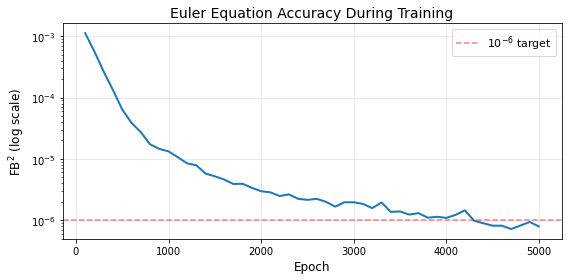

In [11]:
# === Plot 1: Convergence ===
epochs_h = [h[0] for h in history]
fb2_h = [h[1] for h in history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(epochs_h, fb2_h, linewidth=2, color='#1f77b4')
ax.axhline(1e-6, color='red', linestyle='--', alpha=0.5, label='$10^{-6}$ target')
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("FB$^2$ (log scale)", fontsize=12)
ax.set_title("Euler Equation Accuracy During Training", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

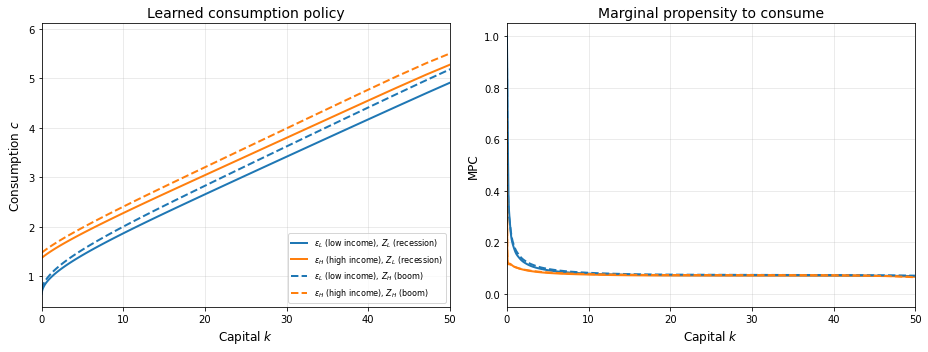

Shape check for trained policy in the final plotted state:
  min Δc across grid intervals      =  5.641e-03  (should be >= 0)
  max(c - cash on hand)             = -5.247e-04  (should be <= 0)
  MPC range on intervals            = [ 0.009,  0.633]
  max increase in MPC across k-grid = -3.123e-05  (should be <= 0)


In [12]:
# === Plot 2: Learned Policy Functions ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#1f77b4", "#ff7f0e"]
labels_eps = [r"$\varepsilon_L$ (low income)", r"$\varepsilon_H$ (high income)"]
labels_Z = ["$Z_L$ (recession)", "$Z_H$ (boom)"]

# Mean K from buffer distributions
buf_K = float(np.mean([
    np.sum(np.asarray(m) * np.asarray(k_grid)[None, :]) for m in buffer_mu
]))

for z_idx in range(N_Z):
    z_hist = jnp.full(H, z_idx, dtype=jnp.int32)
    agg_input = encode_Z_history(z_hist)
    R, w = compute_prices(max(buf_K, 0.01), 1.0, float(Z_VALS[z_idx]))
    c_grid_learned = np.asarray(actor_c_grid(psi, agg_input, float(R), float(w)))

    ls = '-' if z_idx == 0 else '--'
    for e in range(N_EPS):
        m = float(w) * float(EPS_VALS[e]) + float(R) * k_np
        axes[0].plot(k_np, c_grid_learned[e], color=colors[e], linestyle=ls,
                     linewidth=2, label=f"{labels_eps[e]}, {labels_Z[z_idx]}")

        # MPC at k=0: consumption as fraction of cash-on-hand (= boundary MPC α)
        mpc = np.zeros_like(k_np)
        mpc[0] = c_grid_learned[e, 0] / max(m[0], 1e-10)
        # MPC at k>0: finite-difference Δc/Δm = Δc/(R·Δk), matches I-spline MPC by construction
        mpc[1:] = np.diff(c_grid_learned[e]) / (float(R) * np.asarray(dk))
        axes[1].plot(k_np, mpc, color=colors[e], linestyle=ls, linewidth=2)

axes[0].set_xlabel("Capital $k$", fontsize=12)
axes[0].set_ylabel("Consumption $c$", fontsize=12)
axes[0].set_title("Learned consumption policy", fontsize=14)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, min(50, K_MAX))

axes[1].set_xlabel("Capital $k$", fontsize=12)
axes[1].set_ylabel("MPC", fontsize=12)
axes[1].set_title("Marginal propensity to consume", fontsize=14)
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, min(50, K_MAX))

plt.tight_layout()
plt.show()

# shape_report (defined in the initial-visualization cell above) verifies
# the four I-spline guarantees: c increasing, feasible, MPC ∈ [0,1], MPC decreasing
shape_report(c_grid_learned, float(R), float(w), "trained policy in the final plotted state")

---
# Part 7: Euler Error Diagnostics

A single FB² number tells us the average accuracy, but not **where** the policy is good or bad. To diagnose this, we evaluate the per-grid-point Euler gap $|g|$ and Fischer-Burmeister residual $|FB|$ across all replay buffer states.

Two diagnostic plots:
1. **Consumption and MPC vs $K$**: how does the policy respond to different aggregate capital levels? (Approximate aggregation predicts these should be tight clouds.)
2. **Euler / FB error bands**: median and 10th–90th percentile bands of $|FB|$ across the individual capital grid, separately for each income state $\varepsilon$.

In [13]:
# === Euler Error Diagnostics ===

def euler_diagnostics_one_state(psi, z_history, mu):
    """Per-grid-point Euler gap (g) and FB residual for one buffer state.

    Same computation as fb_loss_one_state but returns the full (eps, k) grids
    instead of a scalar mean, plus the consumption and MPC schedules.
    """
    z_t = z_history[-1]

    K_t, L_t = distribution_aggregates(mu)
    R_t, w_t = compute_prices(float(K_t), float(L_t), Z_VALS[z_t])
    R_t_f, w_t_f = float(R_t), float(w_t)

    agg_input = encode_Z_history(z_history)
    c_grid_t = actor_c_grid(psi, agg_input, R_t_f, w_t_f)

    m_grid = w_t_f * EPS_VALS[:, None] + R_t_f * k_grid[None, :]
    k_next_grid = jnp.clip(m_grid - c_grid_t, 0.0, k_grid[-1])

    # Next-period aggregates from Young step
    mu_next = distribution_step(mu, c_grid_t, R_t_f, w_t_f)
    K_next, L_next = distribution_aggregates(mu_next)
    K_next_f, L_next_f = float(K_next), float(L_next)

    q = jnp.zeros_like(c_grid_t)
    for z_next in range(N_Z):
        z_hist_next = jnp.concatenate([z_history[1:], jnp.array([z_next])])
        agg_next = encode_Z_history(z_hist_next)
        R_next, w_next = compute_prices(K_next_f, L_next_f, Z_VALS[z_next])
        R_nf, w_nf = float(R_next), float(w_next)
        c_grid_next = actor_c_grid(psi, agg_next, R_nf, w_nf)

        def _interp_next(i_next):
            k_flat = k_next_grid.ravel()
            idx = jnp.full(k_flat.shape, i_next, dtype=jnp.int32)
            return interpolate(c_grid_next, idx, k_flat).reshape(N_EPS, N + 1)

        c_next_all = jax.vmap(_interp_next)(jnp.arange(N_EPS))
        mu_u = 1.0 / jnp.maximum(c_next_all, 1e-10)
        exp_uc = jnp.einsum('ij,jik->ik', PI_EPS, mu_u)
        q += PI_Z[z_t, z_next] * BETA * R_nf * exp_uc

    c_euler = 1.0 / jnp.maximum(q, 1e-10)
    c_scale = jnp.maximum(c_grid_t, 1e-10)
    g_grid = (c_euler - c_grid_t) / c_scale
    s_grid = k_next_grid / c_scale
    fb_grid = jnp.sqrt(g_grid**2 + s_grid**2 + 1e-12) - g_grid - s_grid

    # MPC via finite-difference (= I-spline MPC at grid points by construction)
    c_np = np.asarray(c_grid_t)
    m_np = np.asarray(m_grid)
    mpc = np.zeros_like(c_np)
    mpc[:, 0] = c_np[:, 0] / np.maximum(m_np[:, 0], 1e-10)
    mpc[:, 1:] = np.diff(c_np, axis=1) / (R_t_f * np.asarray(dk)[None, :])

    return {
        "K": float(K_t), "c_grid": c_np, "mpc_grid": mpc,
        "g_grid": np.asarray(g_grid), "fb_grid": np.asarray(fb_grid),
    }

# Evaluate on all buffer states
print(f"Running Euler diagnostics on {len(buffer_z)} buffer states...")
diag_results = []
for i in range(len(buffer_z)):
    d = euler_diagnostics_one_state(
        psi, jnp.array(buffer_z[i]), jnp.array(buffer_mu[i])
    )
    diag_results.append(d)

all_K = np.array([d["K"] for d in diag_results])
all_c = np.stack([d["c_grid"] for d in diag_results])        # (n_states, N_EPS, N+1)
all_mpc = np.stack([d["mpc_grid"] for d in diag_results])    # (n_states, N_EPS, N+1)
abs_g = np.abs(np.stack([d["g_grid"] for d in diag_results]))
abs_fb = np.abs(np.stack([d["fb_grid"] for d in diag_results]))

print(f"K range: [{all_K.min():.2f}, {all_K.max():.2f}]")
print(f"Mean |g| = {abs_g.mean():.2e},  Mean FB² = {(abs_fb**2).mean():.2e}")

Running Euler diagnostics on 128 buffer states...


K range: [7.43, 9.60]
Mean |g| = 1.04e-03,  Mean FB² = 8.58e-07


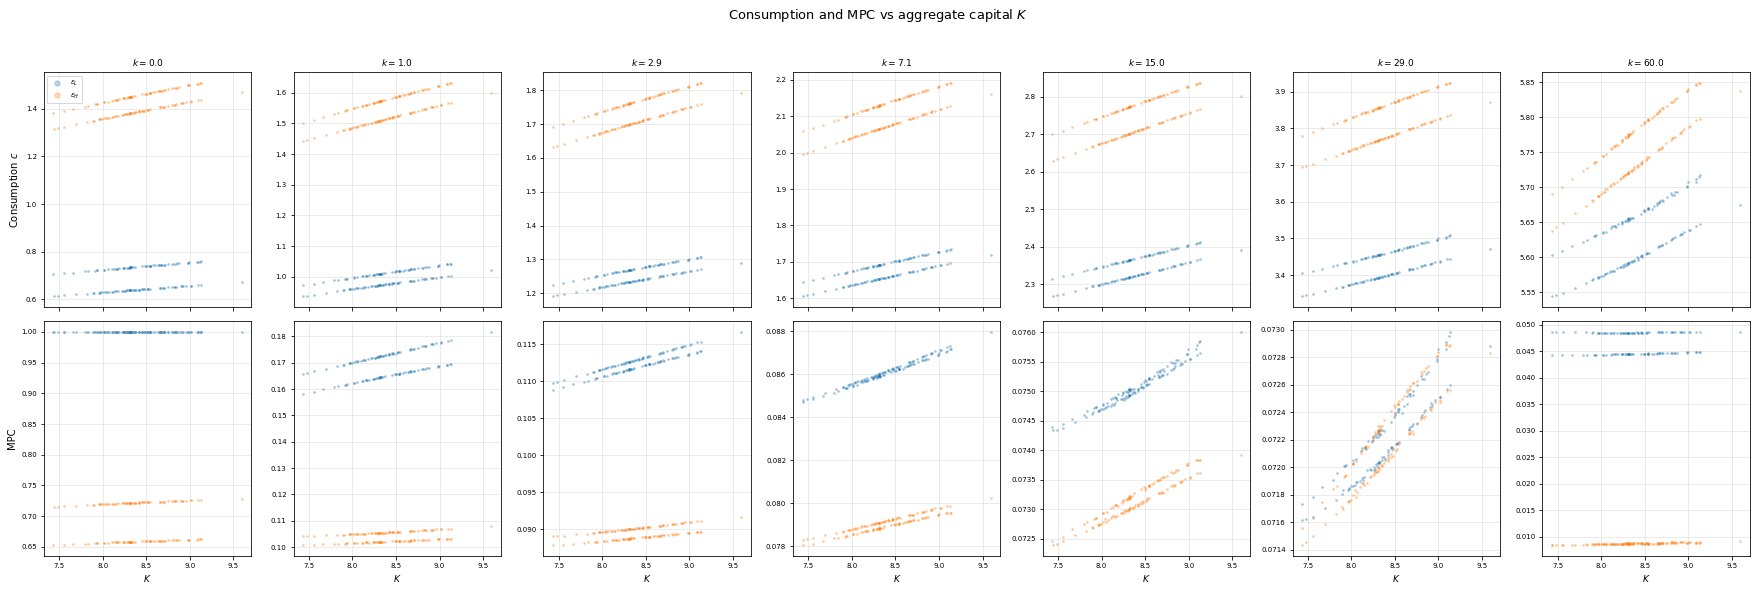

Each column is a fixed individual capital level k.
Variation across K comes from the encoder mapping different Z-histories to different policy coefficients.


In [14]:
# === Scatter: Consumption and MPC vs Aggregate Capital K ===
# At selected individual capital levels, how do c and MPC vary with the
# aggregate state?  Tight scatter clouds = approximate aggregation holds.

target_k_vals = [0.0, 1.0, 3.0, 7.0, 15.0, 30.0, float(k_np[-1])]
target_k_vals = [tk for tk in target_k_vals if tk <= float(k_np[-1])]
k_indices = [int(np.argmin(np.abs(k_np - tk))) for tk in target_k_vals]

colors_eps = ["#1f77b4", "#ff7f0e"]
eps_labels = [r"$\varepsilon_L$", r"$\varepsilon_H$"]

fig, axes = plt.subplots(2, len(k_indices), figsize=(3.5 * len(k_indices), 8),
                         sharex=True)
for col, ki in enumerate(k_indices):
    for e in range(N_EPS):
        axes[0, col].scatter(all_K, all_c[:, e, ki], s=3, alpha=0.3,
                             color=colors_eps[e],
                             label=eps_labels[e] if col == 0 else None)
        axes[1, col].scatter(all_K, all_mpc[:, e, ki], s=3, alpha=0.3,
                             color=colors_eps[e])

    axes[0, col].set_title(f"$k = {k_np[ki]:.1f}$", fontsize=9)
    axes[1, col].set_xlabel("$K$", fontsize=9)
    axes[0, col].grid(True, alpha=0.3)
    axes[1, col].grid(True, alpha=0.3)
    axes[0, col].tick_params(labelsize=7)
    axes[1, col].tick_params(labelsize=7)

axes[0, 0].set_ylabel("Consumption $c$")
axes[1, 0].set_ylabel("MPC")
axes[0, 0].legend(fontsize=7, markerscale=3)
fig.suptitle("Consumption and MPC vs aggregate capital $K$", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Each column is a fixed individual capital level k.")
print("Variation across K comes from the encoder mapping different Z-histories to different policy coefficients.")

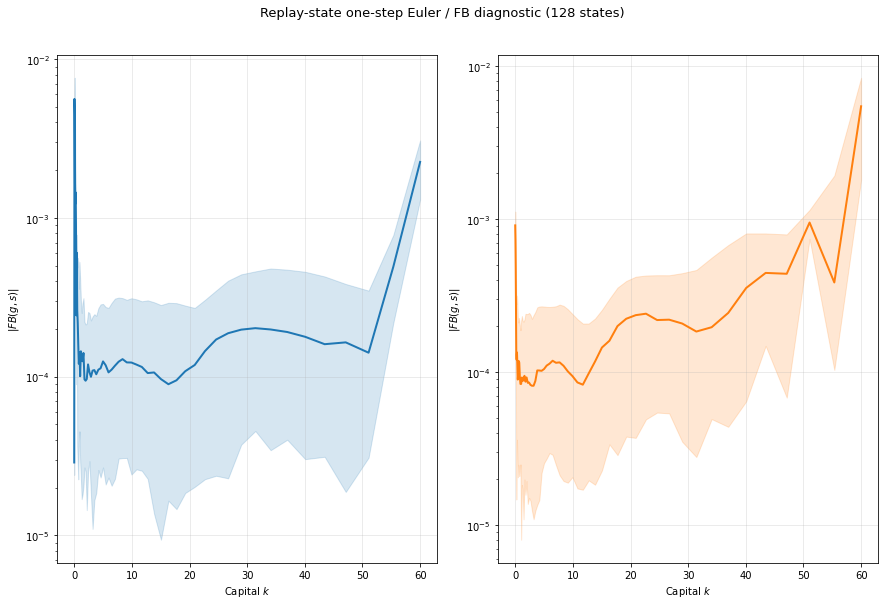

The band shows the 10th–90th percentile range across buffer states.
Wider bands indicate more variation in accuracy across aggregate states.
High |g| near k=0 reflects the borrowing constraint; high |g| at high k
is often on grid points with zero household mass.


In [15]:
# === Euler / FB Error Bands ===
# Median (line) and 10th–90th percentile (band) of |g| and |FB(g,s)|
# across replay buffer states, for each income state.

n_states = abs_g.shape[0]
fig, axes = plt.subplots(1, N_EPS, figsize=(6.2 * N_EPS, 8.2), sharex=True)

for i in range(N_EPS):
    fb_med = np.median(abs_fb[:, i, :], axis=0)
    fb_p10 = np.percentile(abs_fb[:, i, :], 10.0, axis=0)
    fb_p90 = np.percentile(abs_fb[:, i, :], 90.0, axis=0)

    # |FB| panel
    axes[i].fill_between(k_np, np.maximum(fb_p10, 1e-12),
                            np.maximum(fb_p90, 1e-12),
                            color=colors_eps[i], alpha=0.18)
    axes[i].plot(k_np, np.maximum(fb_med, 1e-12),
                    color=colors_eps[i], linewidth=2.0)
    axes[i].set_yscale("log")
    axes[i].set_ylabel(r"$|FB(g,s)|$")
    axes[i].set_xlabel("Capital $k$")
    axes[i].grid(True, alpha=0.3)



fig.suptitle(
    f"Replay-state one-step Euler / FB diagnostic ({n_states} states)",
    fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("The band shows the 10th–90th percentile range across buffer states.")
print("Wider bands indicate more variation in accuracy across aggregate states.")
print("High |g| near k=0 reflects the borrowing constraint; high |g| at high k")
print("is often on grid points with zero household mass.")

---
# Summary

In this notebook we:

1. **Represented** the consumption policy with an I-spline MPC basis, so the grid policy is increasing, concave, and feasible by construction.
2. **Evaluated** equilibrium conditions with a Fischer-Burmeister residual that handles both interior and constrained households.
3. **Trained** on a replay buffer of aggregate histories and household distributions.
4. **Diagnosed** solution quality with per-grid-point Euler error bands and scatter plots showing how the policy varies with the aggregate state.

**Takeaways**
- The I-spline MPC representation gives a concrete example of how economic shape restrictions can be built directly into a neural network.
- The replay buffer is the bridge between individual policies and aggregate prices.
- The scatter plot of consumption vs $K$ at fixed $k$ visualizes approximate aggregation — tight clouds mean the policy depends mainly on prices, not on the full distribution.
- The Euler/FB error band plot reveals where accuracy is best (interior $k$) and worst (near constraints and at high $k$ with zero household mass).

**A few intentional simplifications**
- two-state aggregate and idiosyncratic Markov chains,
- log utility,
- a deterministic $K_{ss}$ used only as a benchmark line.

Once this notebook feels comfortable, the GPU version shows how to move the same logic into a fully JIT-compiled training loop (still working on it).